In [1]:
import pandas as pd

df = pd.read_csv('laptop_data.csv')

print(df.head())



   Unnamed: 0.1  Unnamed: 0   brand                                  name  \
0             0           0      HP      Victus 15-fb0157AX Gaming Laptop   
1             1           1      HP                   15s-fq5007TU Laptop   
2             2           2    Acer                  One 14 Z8-415 Laptop   
3             3           3  Lenovo  Yoga Slim 6 14IAP8 82WU0095IN Laptop   
4             4           4   Apple       MacBook Air 2020 MGND3HN Laptop   

   price  spec_rating                      processor  \
0  49900    73.000000      5th Gen AMD Ryzen 5 5600H   
1  39900    60.000000   12th Gen Intel Core i3 1215U   
2  26990    69.323529  11th Gen Intel Core i3 1115G4   
3  59729    66.000000   12th Gen Intel Core i5 1240P   
4  69990    69.323529                       Apple M1   

                              CPU   Ram Ram_type    ROM ROM_type  \
0           Hexa Core, 12 Threads   8GB     DDR4  512GB      SSD   
1  Hexa Core (2P + 4E), 8 Threads   8GB     DDR4  512GB      SSD

In [2]:
print("\nShape:")
print(df.shape)



Shape:
(893, 18)


In [3]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='object')


In [4]:
# Dataset information
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [5]:
# Remove unnecessary columns
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)

print(df.head())
print(df.shape)

    brand                                  name  price  spec_rating  \
0      HP      Victus 15-fb0157AX Gaming Laptop  49900    73.000000   
1      HP                   15s-fq5007TU Laptop  39900    60.000000   
2    Acer                  One 14 Z8-415 Laptop  26990    69.323529   
3  Lenovo  Yoga Slim 6 14IAP8 82WU0095IN Laptop  59729    66.000000   
4   Apple       MacBook Air 2020 MGND3HN Laptop  69990    69.323529   

                       processor                             CPU   Ram  \
0      5th Gen AMD Ryzen 5 5600H           Hexa Core, 12 Threads   8GB   
1   12th Gen Intel Core i3 1215U  Hexa Core (2P + 4E), 8 Threads   8GB   
2  11th Gen Intel Core i3 1115G4            Dual Core, 4 Threads   8GB   
3   12th Gen Intel Core i5 1240P  12 Cores (4P + 8E), 16 Threads  16GB   
4                       Apple M1             Octa Core (4P + 4E)   8GB   

  Ram_type    ROM ROM_type                           GPU  display_size  \
0     DDR4  512GB      SSD       4GB AMD Radeon RX 650

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print(df.dtypes)

brand                 object
name                  object
price                  int64
spec_rating          float64
processor             object
CPU                   object
Ram                   object
Ram_type              object
ROM                   object
ROM_type              object
GPU                   object
display_size         float64
resolution_width     float64
resolution_height    float64
OS                    object
warranty               int64
dtype: object


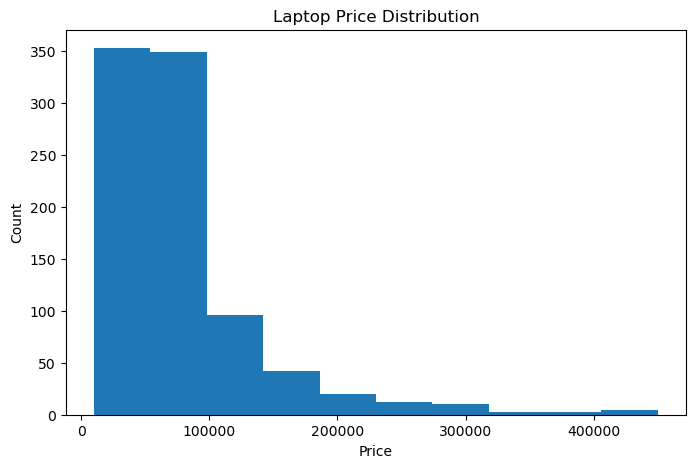

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'])
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Laptop Price Distribution')
plt.show()

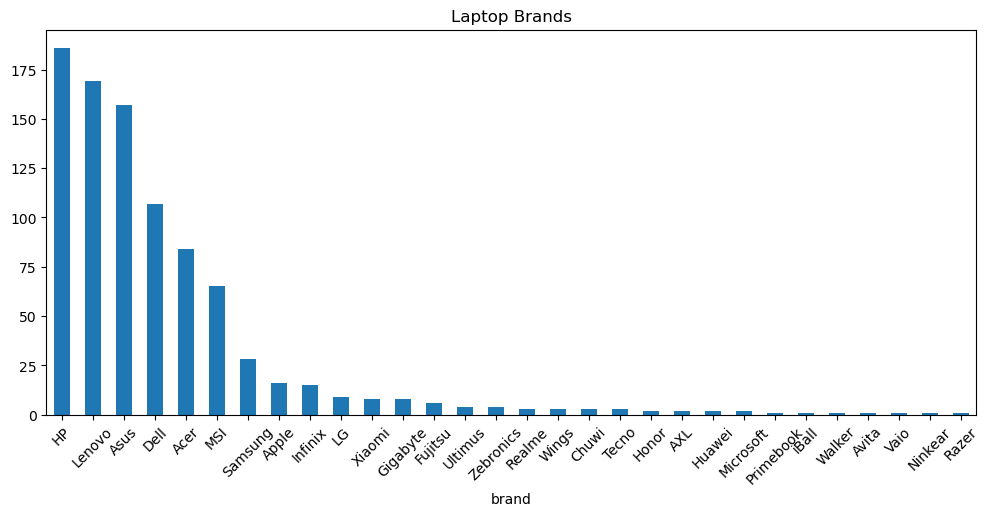

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


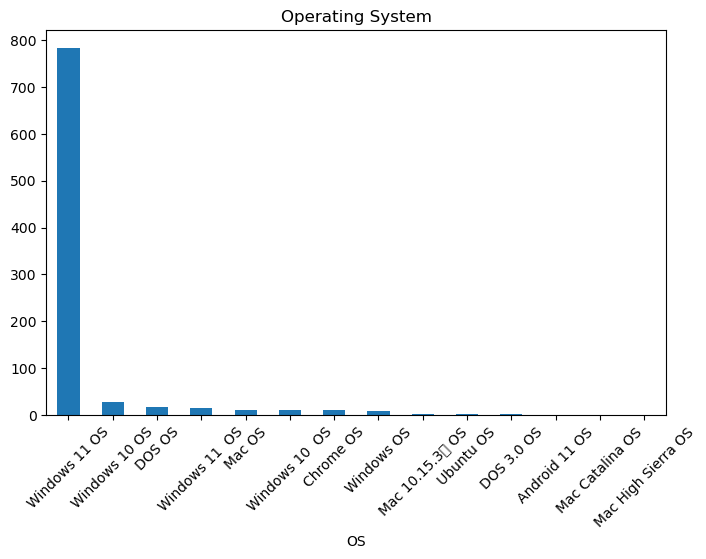

<Figure size 1200x500 with 0 Axes>

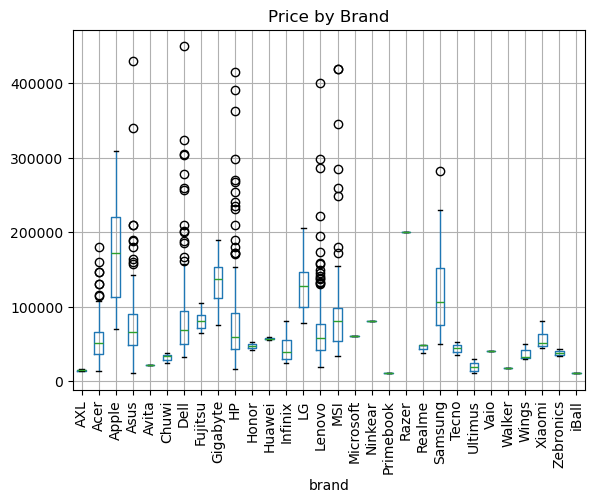

In [9]:
import matplotlib.pyplot as plt

# Brand Distribution
plt.figure(figsize=(12,5))
df['brand'].value_counts().plot(kind='bar')
plt.title('Laptop Brands')
plt.xticks(rotation=45)
plt.show()


# Operating System Distribution
plt.figure(figsize=(8,5))
df['OS'].value_counts().plot(kind='bar')
plt.title('Operating System')
plt.xticks(rotation=45)
plt.show()


# Price vs Brand
plt.figure(figsize=(12,5))
df.boxplot(column='price', by='brand', rot=90)
plt.title('Price by Brand')
plt.suptitle('')
plt.show()

In [10]:
# Remove GB from RAM
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = df['Ram'].astype(int)

print(df['Ram'].head())

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64


In [11]:
print(df['ROM'].unique()[:20])

['512GB' '256GB' '128GB' '64GB' '1TB' '32GB' '2TB']


In [12]:
def convert_rom(x):
    x = str(x).upper().replace(' ', '')

    if 'TB' in x:
        return float(x.replace('TB', '')) * 1024
    elif 'GB' in x:
        return float(x.replace('GB', ''))
    else:
        return float(x)

df['ROM'] = df['ROM'].apply(convert_rom)

print(df['ROM'].head())

0    512.0
1    512.0
2    512.0
3    512.0
4    256.0
Name: ROM, dtype: float64


In [13]:
def get_cpu_brand(x):
    x = str(x)

    if 'Intel' in x:
        return 'Intel'
    elif 'AMD' in x:
        return 'AMD'
    elif 'Apple' in x:
        return 'Apple'
    else:
        return 'Other'

df['CPU_Brand'] = df['processor'].apply(get_cpu_brand)

print(df[['processor','CPU_Brand']].head())

                       processor CPU_Brand
0      5th Gen AMD Ryzen 5 5600H       AMD
1   12th Gen Intel Core i3 1215U     Intel
2  11th Gen Intel Core i3 1115G4     Intel
3   12th Gen Intel Core i5 1240P     Intel
4                       Apple M1     Apple


In [14]:
def get_gpu_brand(x):
    x = str(x)

    if 'NVIDIA' in x:
        return 'NVIDIA'
    elif 'AMD' in x or 'Radeon' in x:
        return 'AMD'
    elif 'Intel' in x:
        return 'Intel'
    elif 'Apple' in x:
        return 'Apple'
    else:
        return 'Other'

df['GPU_Brand'] = df['GPU'].apply(get_gpu_brand)

print(df[['GPU','GPU_Brand']].head())

                            GPU GPU_Brand
0       4GB AMD Radeon RX 6500M       AMD
1            Intel UHD Graphics     Intel
2        Intel Iris Xe Graphics     Intel
3      Intel Integrated Iris Xe     Intel
4  Apple M1 Integrated Graphics     Apple


In [15]:
df['Resolution'] = (
    df['resolution_width'] *
    df['resolution_height']
)

print(df['Resolution'].head())

0    2073600.0
1    2073600.0
2    2073600.0
3    3136000.0
4    4096000.0
Name: Resolution, dtype: float64


In [16]:
df = df.drop([
    'name',
    'processor',
    'CPU',
    'GPU',
    'resolution_width',
    'resolution_height'
], axis=1)

print(df.head())
print(df.shape)

    brand  price  spec_rating  Ram Ram_type    ROM ROM_type  display_size  \
0      HP  49900    73.000000    8     DDR4  512.0      SSD          15.6   
1      HP  39900    60.000000    8     DDR4  512.0      SSD          15.6   
2    Acer  26990    69.323529    8     DDR4  512.0      SSD          14.0   
3  Lenovo  59729    66.000000   16   LPDDR5  512.0      SSD          14.0   
4   Apple  69990    69.323529    8     DDR4  256.0      SSD          13.3   

              OS  warranty CPU_Brand GPU_Brand  Resolution  
0  Windows 11 OS         1       AMD       AMD   2073600.0  
1  Windows 11 OS         1     Intel     Intel   2073600.0  
2  Windows 11 OS         1     Intel     Intel   2073600.0  
3  Windows 11 OS         1     Intel     Intel   3136000.0  
4         Mac OS         1     Apple     Apple   4096000.0  
(893, 13)


In [17]:
print(df.select_dtypes(include='object').columns)

Index(['brand', 'Ram_type', 'ROM_type', 'OS', 'CPU_Brand', 'GPU_Brand'], dtype='object')


In [18]:
X = df.drop('price', axis=1)
y = df['price']

print(X.shape)
print(y.shape)

(893, 12)
(893,)


In [19]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(893, 67)
   spec_rating  Ram    ROM  display_size  warranty  Resolution  brand_Acer  \
0    73.000000    8  512.0          15.6         1   2073600.0       False   
1    60.000000    8  512.0          15.6         1   2073600.0       False   
2    69.323529    8  512.0          14.0         1   2073600.0        True   
3    66.000000   16  512.0          14.0         1   3136000.0       False   
4    69.323529    8  256.0          13.3         1   4096000.0       False   

   brand_Apple  brand_Asus  brand_Avita  ...  OS_Windows 11  OS  \
0        False       False        False  ...              False   
1        False       False        False  ...              False   
2        False       False        False  ...              False   
3        False       False        False  ...              False   
4         True       False        False  ...              False   

   OS_Windows 11 OS  OS_Windows OS  CPU_Brand_Apple  CPU_Brand_Intel  \
0              True          False            

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(714, 67)
(179, 67)


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [22]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[ 89106.65833333  68518.49650794  68746.99916667 127647.81
  88355.16583333  66958.02        53885.91945238  45545.42737662
  78003.5375      16997.265     ]


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))

R2 Score : 0.8326688330945081
MAE : 13869.76011526195


In [24]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error

et = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42
)

et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_et))
print("MAE :", mean_absolute_error(y_test, y_pred_et))

R2 Score : 0.7993620832870934
MAE : 14310.559996138158


In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_lr))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))

R2 Score : 0.7975610572959615
MAE : 18416.402462756116


In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_dt))
print("MAE :", mean_absolute_error(y_test, y_pred_dt))

R2 Score : 0.6311589421536117
MAE : 19464.570818923472


In [27]:
results = {
    "Model": [
        "Random Forest",
        "Extra Trees",
        "Linear Regression",
        "Decision Tree"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_et),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt)
    ]
}

import pandas as pd

result_df = pd.DataFrame(results)

print(result_df)

               Model  R2 Score
0      Random Forest  0.832669
1        Extra Trees  0.799362
2  Linear Regression  0.797561
3      Decision Tree  0.631159


In [28]:
import os
import joblib

# model folder બનાવો જો ન હોય
os.makedirs('model', exist_ok=True)

# model save કરો
joblib.dump(rf, 'model/laptop_price_model.pkl')

# columns save કરો
joblib.dump(X.columns.tolist(), 'model/model_columns.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [29]:
import joblib

joblib.dump(rf, 'model/laptop_price_model.pkl')
joblib.dump(X.columns.tolist(), 'model/model_columns.pkl')

print("Saved successfully")

Saved successfully


In [30]:
import os

print(os.listdir("model"))

['laptop_price_model.pkl', 'model_columns.pkl']


In [31]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [32]:
print(X_train.shape)

(714, 67)


In [33]:
import os
import joblib

save_path = r"C:\Users\patel\OneDrive\Desktop\Documents\Laptop_Price_Prediction\model"

os.makedirs(save_path, exist_ok=True)

# model save
joblib.dump(
    rf,
    os.path.join(save_path, "laptop_price_model.pkl")
)

# columns save
joblib.dump(
    X_train.columns.tolist(),
    os.path.join(save_path, "model_columns.pkl")
)

print("✅ Saved Successfully!")
print(os.listdir(save_path))

✅ Saved Successfully!
['laptop_price_model.pkl', 'model_columns.pkl']


In [34]:
import joblib

try:
    model = joblib.load("model/laptop_price_model.pkl")
    print("Model loaded")
except Exception as e:
    print(e)

Model loaded


In [35]:
print(X_train.columns.tolist())

['spec_rating', 'Ram', 'ROM', 'display_size', 'warranty', 'Resolution', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'Ram_type_DDR3', 'Ram_type_DDR4', 'Ram_type_DDR4-', 'Ram_type_DDR5', 'Ram_type_LPDDR4', 'Ram_type_LPDDR4X', 'Ram_type_LPDDR4x', 'Ram_type_LPDDR5', 'Ram_type_LPDDR5X', 'Ram_type_LPDDR5x', 'Ram_type_Unified', 'ROM_type_SSD', 'OS_Chrome OS', 'OS_DOS 3.0 OS', 'OS_DOS OS', 'OS_Mac 10.15.3\t OS', 'OS_Mac Catalina OS', 'OS_Mac High Sierra OS', 'OS_Mac OS', 'OS_Ubuntu OS', 'OS_Windows 10  OS', 'OS_Windows 10 OS', 'OS_Windows 11  OS', 'OS_Windows 11 OS', 'OS_Windows OS', 'CPU_Bra

In [36]:
import sys
!{sys.executable} -m pip install fpdf2

Defaulting to user installation because normal site-packages is not writeable


In [37]:
from fpdf import FPDF
print("PDF WORKING")

PDF WORKING


In [38]:
import matplotlib.pyplot as plt
print("Matplotlib WORKING")

Matplotlib WORKING
